Accuracy:  1.0


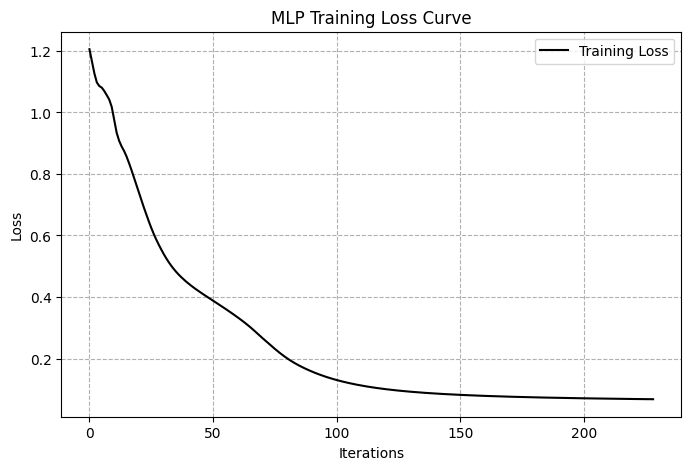

In [ ]:
#Example:1

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mlp_sgd = MLPClassifier(
 hidden_layer_sizes=(16, 8),
 activation='relu',
 solver='sgd',
learning_rate_init=0.01,
 momentum=0.9,
 max_iter=500,
 random_state=42
)
# Train Model
mlp_sgd.fit(X_train, y_train)
# Predict
y_pred = mlp_sgd.predict(X_test)
print("Accuracy: ", mlp_sgd.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(mlp_sgd.loss_curve_, color='black', label='Training Loss')
plt.title('MLP Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()


In [ ]:
#Example:2

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mlp_sgd = MLPClassifier(
 hidden_layer_sizes=(16, 8),
 activation='relu',
 solver='sgd',
learning_rate_init=0.01,
 momentum=0.9,
 max_iter=500,
 random_state=42
)

param_grid = {
'hidden_layer_sizes': [(10,), (20,), (10,10)],
'activation': ['relu', 'tanh'],
'learning_rate_init': [0.001, 0.01],
'alpha': [0.0001, 0.001]
}

# Grid search
grid = GridSearchCV(mlp_sgd, param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (10,), 'learning_rate_init': 0.001}
Best Score: 0.975


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
#Example:3

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svm_model = SVC(kernel='linear', C=1)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Number of Support Vectors:",svm_model.n_support_)
print("Weights (w):",svm_model.coef_)
print("Bias (b):", svm_model.intercept_)

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Number of Support Vectors: [ 3 11 11]
Weights (w): [[-0.04631136  0.52105578 -1.0030165  -0.46411816]
 [-0.00641373  0.17867392 -0.5389119  -0.29158729]
 [ 0.56766907  1.21519237 -2.03626115 -1.70330734]]
Bias (b): [1.45338269 1.50537328 5.8028791 ]


In [2]:
#Excercise:1

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

data=pd.read_csv('data.csv')
X=data.iloc[:,2:]
y=data.iloc[:,1]

# Drop columns from X that contain any NaN values to prevent ValueError in MLPClassifier
X = X.dropna(axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

mlp = MLPClassifier(max_iter=1000, random_state=42)

param_grid = {
    'hidden_layer_sizes': [(10,), (20,), (30,), (20,10)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001],
    'solver': ['adam']
}

grid = GridSearchCV(mlp, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Hyperparameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Hyperparameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (20,), 'learning_rate_init': 0.01, 'solver': 'adam'}
Best CV Accuracy: 0.9748101265822784


In [3]:
#Excercise:2

import pandas as pd
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

mlp = MLPClassifier(max_iter=1000, random_state=42)

warnings.filterwarnings("ignore", category=ConvergenceWarning)

param_grid = {
    'hidden_layer_sizes': [(8,), (16,), (32,), (16,8)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001, 0.01],
    'solver': ['adam']
}

grid = GridSearchCV(mlp, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Hyperparameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Hyperparameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (8,), 'learning_rate_init': 0.001, 'solver': 'adam'}
Best CV Accuracy: 0.7691069574247145


In [6]:
#Exercise:3

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("titanic.csv")

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

svm_model = SVC(kernel='linear', C=1)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Number of Support Vectors:", svm_model.n_support_)
print("Weights (w):", svm_model.coef_)
print("Bias (b):", svm_model.intercept_)

Accuracy: 0.7761194029850746

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       165
           1       0.72      0.68      0.70       103

    accuracy                           0.78       268
   macro avg       0.76      0.76      0.76       268
weighted avg       0.77      0.78      0.77       268

Number of Support Vectors: [144 150]
Weights (w): [[-1.74244377e-04 -5.81194922e-05 -3.55257574e-05 -9.55487517e-01
  -2.70671895e-06 -1.65260443e-05]]
Bias (b): [-0.29526895]


In [8]:
#Exercise:4

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

data=pd.read_csv('data.csv')
X=data.iloc[:,2:]
y=data.iloc[:,1]

# Drop columns from X that contain any NaN values
X = X.dropna(axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

svm_model = SVC(kernel='linear', C=1)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Support Vectors per class:", svm_model.n_support_)
print("Weights shape:", svm_model.coef_.shape)
print("Bias:", svm_model.intercept_)

Accuracy: 0.9649122807017544

Classification Report:

              precision    recall  f1-score   support

           B       0.95      1.00      0.97       107
           M       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171

Support Vectors per class: [18 17]
Weights shape: (1, 30)
Bias: [-0.17713576]
